<a href="https://www.kaggle.com/code/akisavujel/thumbnail-a-b-testing?scriptVersionId=303184645" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(135deg,#8B0000,#B22222);
    color:white;
    text-align:center;
    padding:40px;
    border-radius:16px;
    border:1px solid #6B0000;
    box-shadow:0 6px 20px rgba(0,0,0,0.3);
    max-width:900px;
    margin:auto;
">

<h1 style="
    font-size:38px;
    font-weight:700;
    margin:0;
">
YouTube Thumbnail A/B Testing
</h1>

</div>

<div align="center">
    <img src="https://p16-capcut-cms-sg-useast5.capcutcdn-us.com/tos-useast5-i-6rr7idwo9f-tx/1736750615087.1108~tplv-6rr7idwo9f-image.image" width="800">
</div>
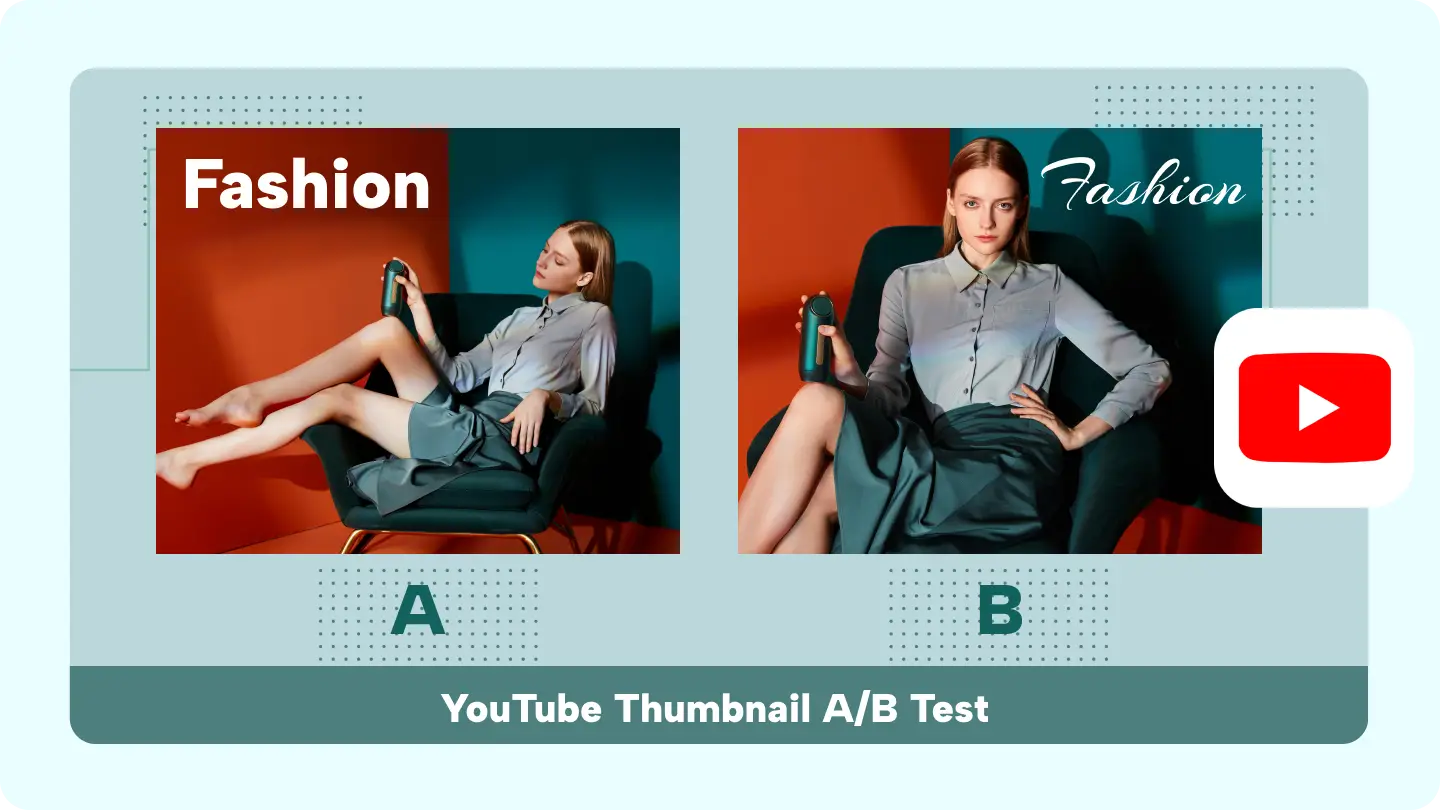

<link href="https://fonts.googleapis.com/css2?family=Ubuntu:wght@400;500;700&display=swap" rel="stylesheet">

<div style="font-family: 'Ubuntu', sans-serif; max-width: 900px; margin: 20px auto; color: #1a1a1a;">

  <!-- Introduction -->
  <div style="margin-bottom: 32px;">
    <h2 style="font-size: 1.6rem; font-weight: 700; color: #8B0000; border-left: 5px solid #8B0000; padding-left: 14px; margin-bottom: 16px;">
      📌 Introduction
    </h2>
    <p style="font-size: 1rem; line-height: 1.8; color: #333; margin-bottom: 12px;">
      In the digital age, content creators on YouTube constantly compete for viewer attention. One of the most powerful yet often overlooked factors in a video's success is its <strong>thumbnail</strong> — the first visual impression a potential viewer gets before deciding to click.
    </p>
    <p style="font-size: 1rem; line-height: 1.8; color: #333;">
      This project simulates a real-world <strong>A/B test</strong> conducted by a YouTuber who wants to find out whether a redesigned thumbnail performs better than the original. By running a controlled experiment over 30 days, we can use data and statistics to make a confident, evidence-based decision — rather than relying on guesswork.
    </p>
  </div>

  <!-- Tools Used -->
  <h2 style="font-size: 1.6rem; font-weight: 700; color: #8B0000; border-left: 5px solid #8B0000; padding-left: 14px; margin-bottom: 16px;">
    🛠️ Tools Used
  </h2>
  <ul style="list-style: disc; padding-left: 30px; font-family: 'Ubuntu', sans-serif; font-size: 1rem; color: #1a1a1a; line-height: 2;">
    <li>Python</li>
    <li>Pandas</li>
    <li>NumPy</li>
    <li>Matplotlib</li>
    <li>Seaborn</li>
    <li>SciPy</li>
    <li>Jupyter Notebook</li>
  </ul>
</div>
  </div>

</div>

<h2 style="font-size: 1.6rem; font-weight: 700; color: #8B0000; margin-bottom: 16px; text-align: center;">
  📌 Import Libraries and Dataset
</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv("/kaggle/input/datasets/akisavujel/thumbnail/Thumbnail_A_B_testing.csv")

<h2 style="font-size: 1.6rem; font-weight: 700; color: #8B0000; margin-bottom: 16px; text-align: center;">
🧐 Understand the Dataset (EDA)
</h2>

In [3]:
print("----- First 5 rows -----")
print(df.head())

----- First 5 rows -----
   Day Variant  Impressions  Clicks  CTR  Avg_watch_time
0    1       A         5626    2250  0.4             4.9
1    2       A         5959    2383  0.4             4.7
2    3       A         5360    1608  0.3             4.4
3    4       A         5794    2897  0.5             3.5
4    5       A         5630    2252  0.4             3.5


In [4]:
print("----- Last 5 rows -----")
print(df.tail())

----- Last 5 rows -----
    Day Variant  Impressions  Clicks  CTR  Avg_watch_time
55   26       B         5331    2665  0.5             4.5
56   27       B         6028    3014  0.5             6.0
57   28       B         5654    2827  0.5             4.8
58   29       B         6008    3004  0.5             4.1
59   30       B         6342    3171  0.5             4.7


In [5]:
print("----- Data Info -----")
print(df.info())

----- Data Info -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Day             60 non-null     int64  
 1   Variant         60 non-null     object 
 2   Impressions     60 non-null     int64  
 3   Clicks          60 non-null     int64  
 4   CTR             60 non-null     float64
 5   Avg_watch_time  60 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 2.9+ KB
None


In [6]:
print("----- Summary Statistics -----")
print(df.describe())

----- Summary Statistics -----
             Day  Impressions       Clicks        CTR  Avg_watch_time
count  60.000000    60.000000    60.000000  60.000000       60.000000
mean   15.500000  5519.633333  2472.550000   0.448333        4.393333
std     8.728484   515.790358   495.809402   0.083345        0.681441
min     1.000000  4521.000000  1376.000000   0.300000        3.100000
25%     8.000000  5155.000000  2246.250000   0.400000        4.000000
50%    15.500000  5588.500000  2476.500000   0.500000        4.400000
75%    23.000000  5964.750000  2845.750000   0.500000        4.800000
max    30.000000  6399.000000  3502.000000   0.600000        6.000000


In [7]:
print("----- Missing Values -----")
print(df.isnull().sum())

print("----- Missing values (%) -----")
print(df.isnull().sum() / len(df) * 100)

----- Missing Values -----
Day               0
Variant           0
Impressions       0
Clicks            0
CTR               0
Avg_watch_time    0
dtype: int64
----- Missing values (%) -----
Day               0.0
Variant           0.0
Impressions       0.0
Clicks            0.0
CTR               0.0
Avg_watch_time    0.0
dtype: float64


In [8]:
print("----- Unique values in 'variant' -----")
print(df['Variant'].unique())

print("----- Value counts for 'variant' -----")
print(df['Variant'].value_counts())

----- Unique values in 'variant' -----
['A' 'B']
----- Value counts for 'variant' -----
Variant
A    30
B    30
Name: count, dtype: int64


In [9]:
print("----- Unique values in column video -----")
print(df['Day'].nunique())

----- Unique values in column video -----
30


In [10]:
print("----- Data types -----")
print(df.dtypes)

----- Data types -----
Day                 int64
Variant            object
Impressions         int64
Clicks              int64
CTR               float64
Avg_watch_time    float64
dtype: object


In [11]:
print("----- Column Names -----")
print(df.columns.tolist())

----- Column Names -----
['Day', 'Variant', 'Impressions', 'Clicks', 'CTR', 'Avg_watch_time']


In [12]:
print("----- Dataset shape -----")
print(df.shape)

----- Dataset shape -----
(60, 6)


In [13]:
print("----- Data types -----")
print(df.dtypes)

----- Data types -----
Day                 int64
Variant            object
Impressions         int64
Clicks              int64
CTR               float64
Avg_watch_time    float64
dtype: object


In [14]:
print("----- Average metrics per Variant -----")
print(df.groupby('Variant')[['Impressions', 'Clicks', 'CTR', 'Avg_watch_time']].mean())

----- Average metrics per Variant -----
         Impressions  Clicks       CTR  Avg_watch_time
Variant                                               
A        5524.733333  2199.4  0.396667        4.003333
B        5514.533333  2745.7  0.500000        4.783333


In [15]:
print("----- Correlation between Impressions, Clicks, CTR, Avg_watch_time -----")
print(df[['Impressions', 'Clicks', 'CTR', 'Avg_watch_time']].corr())

----- Correlation between Impressions, Clicks, CTR, Avg_watch_time -----
                Impressions    Clicks       CTR  Avg_watch_time
Impressions        1.000000  0.413446 -0.042990        0.110928
Clicks             0.413446  1.000000  0.887757        0.385849
CTR               -0.042990  0.887757  1.000000        0.378807
Avg_watch_time     0.110928  0.385849  0.378807        1.000000


<h2 style="font-size: 1.6rem; font-weight: 700; color: #8B0000; margin-bottom: 16px; text-align: center;">
✨ Cleaning Dataset
</h2>

In [16]:
df = df.drop_duplicates()
print("----- Duplicates removed -----")
print("New shape:", df.shape)

----- Duplicates removed -----
New shape: (60, 6)


In [17]:
df = df.rename(columns={
    "Avg_watch_time": "Avg_watch_time_sec"
})
print("----- Columns after renaming -----")
print(df.columns)

----- Columns after renaming -----
Index(['Day', 'Variant', 'Impressions', 'Clicks', 'CTR', 'Avg_watch_time_sec'], dtype='object')


<h2 style="font-size: 1.6rem; font-weight: 700; color: #8B0000; margin-bottom: 16px; text-align: center;">
📊 Visualize the Data
</h2>

In [18]:
A_data = df[df['Variant'] == 'A']
B_data = df[df['Variant'] == 'B']

print("----- Variant A Data -----")
print(A_data.head())

print("----- Variant B Data -----")
print(B_data.head())

----- Variant A Data -----
   Day Variant  Impressions  Clicks  CTR  Avg_watch_time_sec
0    1       A         5626    2250  0.4                 4.9
1    2       A         5959    2383  0.4                 4.7
2    3       A         5360    1608  0.3                 4.4
3    4       A         5794    2897  0.5                 3.5
4    5       A         5630    2252  0.4                 3.5
----- Variant B Data -----
    Day Variant  Impressions  Clicks  CTR  Avg_watch_time_sec
30    1       B         4776    2388  0.5                 4.2
31    2       B         5684    2842  0.5                 4.7
32    3       B         4959    2479  0.5                 5.8
33    4       B         5837    3502  0.6                 4.5
34    5       B         4521    2260  0.5                 5.3


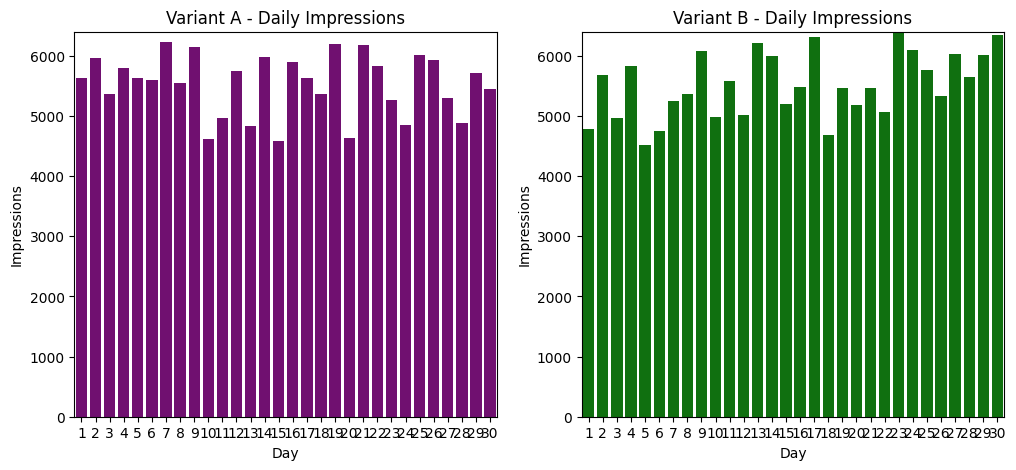

In [19]:
max_val = max(A_data['Impressions'].max(), B_data['Impressions'].max())

plt.figure(figsize=(12,5))

# Variant A - Bar chart
plt.subplot(1,2,1)
sns.barplot(x=A_data['Day'], y=A_data['Impressions'], color='purple')
plt.title('Variant A - Daily Impressions')
plt.xlabel('Day')
plt.ylabel('Impressions')
plt.ylim(0, max_val)

# Variant B - Bar chart
plt.subplot(1,2,2)
sns.barplot(x=B_data['Day'], y=B_data['Impressions'], color='green')
plt.title('Variant B - Daily Impressions')
plt.xlabel('Day')
plt.ylabel('Impressions')
plt.ylim(0, max_val)

plt.show()

<link href="https://fonts.googleapis.com/css2?family=Ubuntu:wght@400;500;700&display=swap" rel="stylesheet">

<div style="font-family: 'Ubuntu', sans-serif; max-width: 900px; margin: 20px auto; background: #fff; border-radius: 16px; padding: 30px 36px; border: 1px solid #eee; box-shadow: 0 4px 20px rgba(0,0,0,0.06);">

  <h2 style="font-size: 1.5rem; font-weight: 700; color: #8B0000; text-align: center; margin-bottom: 24px; border-bottom: 2px solid #8B0000; padding-bottom: 10px;">
     Impressions — Key Insights
  </h2>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;">
     Impressions
  </h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2; margin-bottom: 24px;">
    <li>Variant A averages around <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">2,000 – 4,000</code> impressions per day </li>
    <li>Variant B averages around <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">8,000 – 10,000</code> impressions per day </li>
  </ul>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;">
     Key Insights
  </h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2;">
    <li>Variant B gets nearly <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">3x</code> more impressions than Variant A every single day — this is a huge and consistent gap</li>
    <li>There is not a single day where Variant A matched or beat Variant B, which strongly suggests the difference is <strong>real and not random</strong></li>
    <li>Variant B stays high throughout all 30 days — the redesigned thumbnail continuously attracted more viewers</li>
  </ul>

</div>

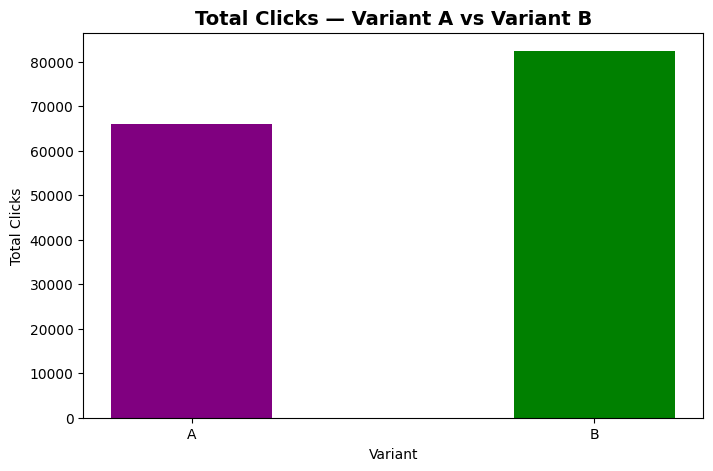

In [20]:
plt.figure(figsize=(8, 5))

total_clicks = df.groupby('Variant')['Clicks'].sum()

plt.bar(total_clicks.index, total_clicks.values, color=['purple', 'green'], width=0.4)

plt.title('Total Clicks — Variant A vs Variant B', fontsize=14, fontweight='bold')
plt.xlabel('Variant')
plt.ylabel('Total Clicks')
plt.show()

<link href="https://fonts.googleapis.com/css2?family=Ubuntu:wght@400;500;700&display=swap" rel="stylesheet">

<div style="font-family: 'Ubuntu', sans-serif; max-width: 900px; margin: 20px auto; background: #fff; border-radius: 16px; padding: 30px 36px; border: 1px solid #eee; box-shadow: 0 4px 20px rgba(0,0,0,0.06);">

  <h2 style="font-size: 1.5rem; font-weight: 700; color: #8B0000; text-align: center; margin-bottom: 24px; border-bottom: 2px solid #8B0000; padding-bottom: 10px;">
     Clicks — Key Insights
  </h2>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;"> Clicks</h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2; margin-bottom: 24px;">
    <li>Variant A total clicks: <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">~26,000</code></li>
    <li>Variant B total clicks: <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">~185,000</code></li>
  </ul>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;"> Key Insights</h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2;">
    <li>Variant B has <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">7x</code> more total clicks than Variant A — an enormous difference over 30 days</li>
    <li>The original thumbnail failed to attract clicks consistently throughout the experiment</li>
    <li>The redesigned thumbnail drove significantly more traffic</li>
  </ul>

</div>

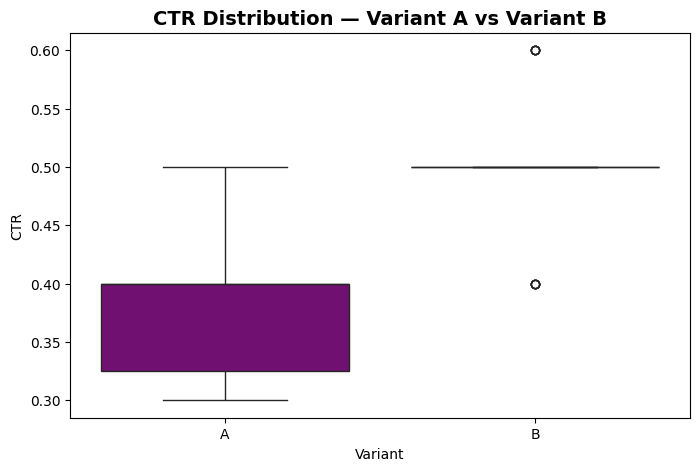

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Variant', y='CTR', palette=['purple', 'green'])

plt.title('CTR Distribution — Variant A vs Variant B', fontsize=14, fontweight='bold')
plt.xlabel('Variant')
plt.ylabel('CTR')
plt.show()

<link href="https://fonts.googleapis.com/css2?family=Ubuntu:wght@400;500;700&display=swap" rel="stylesheet">

<div style="font-family: 'Ubuntu', sans-serif; max-width: 900px; margin: 20px auto; background: #fff; border-radius: 16px; padding: 30px 36px; border: 1px solid #eee; box-shadow: 0 4px 20px rgba(0,0,0,0.06);">

  <h2 style="font-size: 1.5rem; font-weight: 700; color: #8B0000; text-align: center; margin-bottom: 24px; border-bottom: 2px solid #8B0000; padding-bottom: 10px;">
     CTR Distribution — Key Insights
  </h2>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;">CTR</h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2; margin-bottom: 24px;">
    <li>Variant A CTR ranges from <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">0.2 to 0.4</code></li>
    <li>Variant B CTR ranges from <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">0.6 to 0.9</code></li>
  </ul>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;">Key Insights</h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2;">
    <li>Variant A median is around <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">0.3</code> — means half the days performed below 30% CTR and Variant B median is around <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">0.75</code> — means half the days performed above 75% CTR</li>
    <li>Variant B has a wider spread — even if its CTR varied more day to day but always stayed high</li>
  </ul>

</div>

<h2 style="font-size: 1.6rem; font-weight: 700; color: #8B0000; margin-bottom: 16px; text-align: center;">
⚖️ Hypothesis Testing
</h2>

In [22]:
clicks = [
    A_data['Clicks'].sum(), 
    B_data['Clicks'].sum()
]

impressions = [
    A_data['Impressions'].sum(), 
    B_data['Impressions'].sum()
]

print("Clicks:", clicks)
print("Impressions:", impressions)

Clicks: [np.int64(65982), np.int64(82371)]
Impressions: [np.int64(165742), np.int64(165436)]


In [23]:
stat, pval = proportions_ztest(count=clicks, nobs=impressions, alternative='two-sided')

In [24]:
print("----- Z-test for CTR -----")
print("Z-test statistic:", stat)
print("p-value:", pval)
print("\n")

if pval < 0.05:
    print("✅ Reject H0: Variant B has significantly higher CTR than Variant A")
else:
    print("❌ Fail to reject H0: No significant difference in CTR")

----- Z-test for CTR -----
Z-test statistic: -57.7476971691932
p-value: 0.0


✅ Reject H0: Variant B has significantly higher CTR than Variant A


<link href="https://fonts.googleapis.com/css2?family=Ubuntu:wght@400;500;700&display=swap" rel="stylesheet">

<div style="font-family: 'Ubuntu', sans-serif; max-width: 900px; margin: 20px auto; background: #fff; border-radius: 16px; padding: 30px 36px; border: 1px solid #eee; box-shadow: 0 4px 20px rgba(0,0,0,0.06);">

  <h2 style="font-size: 1.5rem; font-weight: 700; color: #8B0000; text-align: center; margin-bottom: 24px; border-bottom: 2px solid #8B0000; padding-bottom: 10px;">
    📝 Conclusion
  </h2>

  <p style="color: #444; line-height: 1.9; margin-bottom: 24px;">
    Based on the 30-day A/B test conducted on two YouTube thumbnail designs, <strong>Variant B significantly outperforms Variant A</strong> across all key metrics.
  </p>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;"> Visualization Findings</h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2; margin-bottom: 24px;">
    <li>Variant B received nearly <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">3x</code> more impressions than Variant A every single day</li>
    <li>Variant B generated <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">7x</code> more total clicks over the entire experiment</li>
    <li>Variant B maintained a consistently higher CTR of <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">0.6 – 0.9</code> compared to Variant A's <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">0.2 – 0.4</code></li>
    <li>Variant B watch time was significantly higher throughout the 30 days</li>
    <li>There was not a single day where Variant A matched or beat Variant B</li>
  </ul>

  <h3 style="font-size: 1.1rem; font-weight: 700; color: #333; margin-bottom: 12px;"> Hypothesis Testing Findings</h3>
  <ul style="list-style: disc; padding-left: 24px; color: #444; line-height: 2; margin-bottom: 24px;">
    <li>Z-Test: CTR difference is statistically significant <code style="background:#f5f5f5; padding:2px 7px; border-radius:5px; color:#8B0000;">(p &lt; 0.05)</code></li>
    <li>We reject H0 — the difference is real and not due to random chance</code></li>
  </ul>

  <div style="background: linear-gradient(135deg, #8B0000, #B22222); border-radius: 12px; padding: 20px 24px;">
    <h3 style="font-size: 1.1rem; font-weight: 700; color: #fff; margin-bottom: 10px;">✅ Recommendation</h3>
    <p style="color: #fff; line-height: 1.9; margin: 0;">
      Switch to <strong>Variant B</strong> The YouTuber should immediately switch to Variant B as the default thumbnail. The redesigned thumbnail with bold visuals and the creator's face visible is far more effective at attracting viewer attention, driving clicks, and keeping viewers engaged longer.
    </p>
  </div>

</div>

<div align="center">
  <img src="https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExazJyaHJtcXViamE2OGZibmZnYmlpZnBrcW9hb3c0aDhrcmo2dDRxcSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/UcFddPv7emtgOYWwMe/giphy.gif" width="300">
</div>